
# LIDC-IDRI Slice Extraction → HDF5
## Data Preparation


### Output
```
/content/slices.h5          ← single HDF5 file, uploaded to HuggingFace
```
Datasets inside slices.h5:
  img      (N, 128, 128) float32  — preprocessed CT slices
  msk      (N, 128, 128) float32  — corresponding lung masks
  patient  (N,)          str      — patient ID
  kind     (N,)          str      — "lung" or "empty"
  file     (N,)          str      — original filename (for debugging)

### Design
- NIfTI volumes downloaded from HuggingFace
- Slices extracted, resized, and written straight into the local HDF5
- HF cache purged after every patient 
- HDF5 uploaded to HuggingFace every UPLOAD_EVERY slices and on completion
- Progress saved after every batch — safe to interrupt and resume
- Heartbeat thread prints every 30 s — Colab session never times out
"""

In [ ]:

# ── Cell 1 — Environment Check ────────────────────────────────────────────────
# Run first to confirm the runtime is ready.

import torch, platform, os, shutil

print("=" * 50)
print("ENVIRONMENT CHECK")
print("=" * 50)
print(f"Python        : {platform.python_version()}")
print(f"PyTorch       : {torch.__version__}")
print(f"CUDA          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

disk = shutil.disk_usage("/")
print(f"Colab disk    : {disk.free / 1e9:.1f} GB free / {disk.total / 1e9:.1f} GB total")
print("=" * 50)

if not torch.cuda.is_available():
    print("NOTE: No GPU detected. Caching will still work on CPU.")
    print("      Go to Runtime > Change runtime type > T4 GPU for faster resizing.")
else:
    print("[Cell 1 OK]")


ENVIRONMENT CHECK
Python        : 3.12.13
PyTorch       : 2.10.0+cu128
CUDA          : True
GPU           : Tesla T4
GPU Memory    : 15.6 GB
Colab disk    : 68.3 GB free / 120.9 GB total
[Cell 1 OK]


In [ ]:
# ── Cell 2 — Install Dependencies ────────────────────────────────────────────

import subprocess, sys

REQUIRED = ["nibabel", "albumentations", "h5py"]
for pkg in REQUIRED:
    try:
        __import__(pkg)
        print(f"  {pkg} : already installed")
    except ImportError:
        print(f"  {pkg} : installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  {pkg} : installed")

import os, re, gc, json, time, random, shutil, threading
import numpy as np
import torch
import torch.nn.functional as F
import nibabel as nib
import h5py
from concurrent.futures import ThreadPoolExecutor, as_completed
from huggingface_hub import HfApi, hf_hub_download, list_repo_files
from tqdm import tqdm

print("\nAll imports OK.")
print("[Cell 2 OK]")

  nibabel : already installed
  albumentations : already installed
  h5py : already installed

All imports OK.
[Cell 2 OK]


In [ ]:
# ── Cell 3 — Configuration ───────────────────────────────────────────────────
# All parameters live here. Edit only this cell.

# ── HuggingFace ───────────────────────────────────────────────────────────────
HF_SOURCE_REPO = "hourouu/LIDC_IDRI_NORMALIZED"   # source NIfTI dataset
HF_OUTPUT_REPO = "hourouu/data_unet128A"                   # destination for slices.h5
N_PATIENTS     = 996

# ── Output paths (local Colab disk only) ──────────────────────────────────────
H5_LOCAL    = "/content/slices.h5"
H5_PROGRESS = "/content/slices_progress.json"

# ── Slice resolution ──────────────────────────────────────────────────────────
# 128x128 justified by Ferreira et al. (2022), Applied Sciences,
# full lung segmentation on LIDC-IDRI at 128x128 — DSC = 0.9502.
# Sabottke & Spieler (2020), Radiology:AI confirms large anatomical
# structures are insensitive to resolution reduction.
IMAGE_SIZE = 128

# ── Slice sampling ────────────────────────────────────────────────────────────
# All valid lung slices are used, clamped between MIN and MAX.
MIN_SLICES_PATIENT = 20
MAX_SLICES_PATIENT = 120

# ── Empty slice strategy ──────────────────────────────────────────────────────
# 10% of lung-slice count added as empty slices per patient.
# Prevents false-positive bias on non-lung slices.
# Justified by Huang et al. (2022), QIMS; Wang et al. (2021), IEEE TMI.
EMPTY_SLICE_RATIO = 0.10
MIN_MASK_RATIO    = 0.001  # below this → slice is classified as empty

# ── Progress & upload behaviour ───────────────────────────────────────────────
CHUNK        = 500   # slices per HDF5 write batch
UPLOAD_EVERY = 5000  # upload checkpoint to HF every N slices
PRINT_EVERY  = 200   # heartbeat print interval (slices)
RANDOM_SEED  = 42

# ── Hardware ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration:")
print(f"  Source repo    : {HF_SOURCE_REPO}")
print(f"  Output repo    : {HF_OUTPUT_REPO}")
print(f"  Patients       : {N_PATIENTS}")
print(f"  Image size     : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Min/Max slices : {MIN_SLICES_PATIENT} / {MAX_SLICES_PATIENT}")
print(f"  Empty ratio    : {EMPTY_SLICE_RATIO} ({int(EMPTY_SLICE_RATIO*100)}%)")
print(f"  HDF5 output    : {H5_LOCAL}")
print(f"  Upload every   : {UPLOAD_EVERY} slices")
print(f"  Device         : {DEVICE}")
print("[Cell 3 OK]")

Configuration:
  Source repo    : hourouu/LIDC_IDRI_NORMALIZED
  Output repo    : hourouu/data_unet128A
  Patients       : 996
  Image size     : 128x128
  Min/Max slices : 20 / 120
  Empty ratio    : 0.1 (10%)
  HDF5 output    : /content/slices.h5
  Upload every   : 5000 slices
  Device         : cuda
[Cell 3 OK]


In [ ]:
# ── Cell 4 — Helper Functions ─────────────────────────────────────────────────

def evenly_spaced_sample(slice_list, n):
    """
    Return n items spread uniformly across slice_list via np.linspace.
    Guarantees top-to-bottom anatomical coverage — no regional clustering.
    Justified by Huang et al. (2022), QIMS — uniform slice distribution
    is critical for representative anatomical coverage in 2D CT segmentation.
    """
    if n >= len(slice_list):
        return slice_list
    indices = np.linspace(0, len(slice_list) - 1, n, dtype=int)
    return [slice_list[i] for i in indices]


def compute_sample_counts(n_lung_slices, min_slices, max_slices, empty_ratio):
    """
    Returns (n_lung_to_sample, n_empty_to_sample) for one patient.
    All valid lung slices are used, clamped between min and max.
    n_lung  = clamp(n_lung_slices, min, max)
    n_empty = max(1, round(n_lung * empty_ratio))
    """
    n_lung  = max(min_slices, min(max_slices, n_lung_slices))
    n_empty = max(1, int(round(n_lung * empty_ratio)))
    return n_lung, n_empty


# ── Sampling preview ──────────────────────────────────────────────────────────
print("Sampling preview (all slices used | min=20 | max=120 | empty=10%):")
for depth, label in [(80, "shallow"), (150, "typical"), (300, "deep")]:
    nl, ne = compute_sample_counts(
        depth,
        MIN_SLICES_PATIENT, MAX_SLICES_PATIENT, EMPTY_SLICE_RATIO
    )
    print(f"  {label:8s} ({depth:3d} lung slices) "
          f"-> {nl:3d} lung + {ne:2d} empty = {nl+ne:3d} total")

print("\n[Cell 4 OK]")

Sampling preview (all slices used | min=20 | max=120 | empty=10%):
  shallow  ( 80 lung slices) ->  80 lung +  8 empty =  88 total
  typical  (150 lung slices) -> 120 lung + 12 empty = 132 total
  deep     (300 lung slices) -> 120 lung + 12 empty = 132 total

[Cell 4 OK]


In [ ]:
# ── Cell 5 — Discover Patient Files ──────────────────────────────────────────
# Lists all image/mask pairs from HuggingFace.
# This is the ONLY call that contacts HuggingFace for the file listing.
# Actual volume downloads happen inside the extraction loop in Cell 6.

print("Listing repository files from HuggingFace...")
print("(This fetches filenames only — no volumes downloaded yet)\n")

all_files = sorted(list_repo_files(HF_SOURCE_REPO, repo_type="dataset"))
img_files = [f for f in all_files if "images/" in f and f.endswith(".nii.gz")]
msk_files = [f for f in all_files if "masks/"  in f and f.endswith(".nii.gz")]

get_pid = lambda f: re.search(r"(LIDC-IDRI-\d+)", f).group(1)
msk_map = {get_pid(f): f for f in msk_files}

# Build patient pairs — only include patients that have both image and mask
pairs = [
    (get_pid(f), f, msk_map[get_pid(f)])
    for f in img_files
    if get_pid(f) in msk_map
]
pairs = pairs[:N_PATIENTS]

print(f"Image files found : {len(img_files)}")
print(f"Mask files found  : {len(msk_files)}")
print(f"Valid pairs       : {len(pairs)}")
print(f"Patients to cache : {N_PATIENTS}")

if len(pairs) < N_PATIENTS:
    print(f"WARNING: only {len(pairs)} valid pairs found, expected {N_PATIENTS}")
else:
    print("All patient pairs verified.")

print("\nSample pairs (first 3):")
for pid, img_f, msk_f in pairs[:3]:
    print(f"  {pid}")
    print(f"    img: {img_f}")
    print(f"    msk: {msk_f}")

print("\n[Cell 5 OK]")

Listing repository files from HuggingFace...
(This fetches filenames only — no volumes downloaded yet)

Image files found : 996
Mask files found  : 996
Valid pairs       : 996
Patients to cache : 996
All patient pairs verified.

Sample pairs (first 3):
  LIDC-IDRI-0001
    img: images/LIDC-IDRI-0001_img.nii.gz
    msk: masks/LIDC-IDRI-0001_msk.nii.gz
  LIDC-IDRI-0002
    img: images/LIDC-IDRI-0002_img.nii.gz
    msk: masks/LIDC-IDRI-0002_msk.nii.gz
  LIDC-IDRI-0003
    img: images/LIDC-IDRI-0003_img.nii.gz
    msk: masks/LIDC-IDRI-0003_msk.nii.gz

[Cell 5 OK]


In [ ]:
# ── Cell 6 — Main Extraction + HDF5 Write ────────────────────────────────────
# FIX: slices_progress.json is now uploaded to HF only when slices.h5 is
# uploaded (every UPLOAD_EVERY slices). Both files stay in sync on HF.
# The per-patient upload of the progress JSON has been removed.

random.seed(RANDOM_SEED)

hf_cache = os.path.expanduser("~/.cache/huggingface/hub")

max_n = N_PATIENTS * (MAX_SLICES_PATIENT + max(1, int(round(MAX_SLICES_PATIENT * EMPTY_SLICE_RATIO))))

# ── Resume state ──────────────────────────────────────────────────────────────
already_done = set()
written      = 0
failed_pids  = []

print("Checking HuggingFace for existing progress...", flush=True)

try:
    hf_hub_download(
        repo_id=HF_OUTPUT_REPO, filename="slices_progress.json",
        repo_type="dataset", local_dir="/content", force_download=True)
    with open(H5_PROGRESS) as f:
        prog = json.load(f)
    already_done = set(prog.get("processed_patients", []))
    failed_pids  = prog.get("failed_patients", [])
    print(f"  Progress found on HF: {len(already_done)} patients done previously.")
except Exception:
    print("  No progress file on HF — starting fresh.")

if already_done:
    if os.path.exists(H5_LOCAL):
        os.remove(H5_LOCAL)
        print("  Removed stale local slices.h5 — re-downloading from HF.", flush=True)
    print(f"  Downloading slices.h5 from HF...", flush=True)
    _start = time.time()
    try:
        hf_hub_download(
            repo_id=HF_OUTPUT_REPO, filename="slices.h5",
            repo_type="dataset", local_dir="/content", force_download=True)
        with h5py.File(H5_LOCAL, "r") as hf:
            written = hf["img"].shape[0]
        print(f"  Downloaded in {round(time.time()-_start, 1)}s — {written} slices.", flush=True)
    except Exception as e:
        raise RuntimeError(f"Could not download slices.h5 from HF: {e}")
else:
    print("  No prior progress — starting fresh.")

remaining = [p for p in pairs if p[0] not in already_done]
if not remaining:
    print(f"All {len(already_done)} patients already processed. Skipping to upload.")

# ── Create or open HDF5 ───────────────────────────────────────────────────────
if written == 0 and not already_done:
    print(f"\nCreating {H5_LOCAL} (pre-allocated for up to {max_n} slices)...")
    with h5py.File(H5_LOCAL, "w") as hf:
        dt = h5py.string_dtype()
        hf.create_dataset("img",     shape=(0, IMAGE_SIZE, IMAGE_SIZE),
                          maxshape=(None, IMAGE_SIZE, IMAGE_SIZE),
                          dtype="float32", chunks=(1, IMAGE_SIZE, IMAGE_SIZE),
                          compression="lzf")
        hf.create_dataset("msk",     shape=(0, IMAGE_SIZE, IMAGE_SIZE),
                          maxshape=(None, IMAGE_SIZE, IMAGE_SIZE),
                          dtype="float32", chunks=(1, IMAGE_SIZE, IMAGE_SIZE),
                          compression="lzf")
        hf.create_dataset("patient", shape=(0,), maxshape=(None,), dtype=dt)
        hf.create_dataset("kind",    shape=(0,), maxshape=(None,), dtype=dt)
        hf.create_dataset("file",    shape=(0,), maxshape=(None,), dtype=dt)
        hf.attrs["image_size"] = IMAGE_SIZE
    print("HDF5 created OK.")
else:
    print(f"\nOpening existing {H5_LOCAL} for append (written={written} slices).")

# ── Heartbeat thread ──────────────────────────────────────────────────────────
_progress = {"patients_done": len(already_done), "slices_written": written}
_hb_stop  = threading.Event()

def _heartbeat():
    while not _hb_stop.wait(30):
        done = _progress["patients_done"]
        sl   = _progress["slices_written"]
        free = shutil.disk_usage("/content").free / 1e9
        print(f"  [{time.strftime('%H:%M:%S')}] "
              f"patients {done}/{N_PATIENTS} | "
              f"slices {sl} | "
              f"{free:.1f} GB free", flush=True)

_hb_thread = threading.Thread(target=_heartbeat, daemon=True)
_hb_thread.start()

# ── Main loop ─────────────────────────────────────────────────────────────────
t0           = time.time()
session_sl   = 0
session_err  = 0
_last_upload = written

try:
    with h5py.File(H5_LOCAL, "a") as hf:
        ds_img     = hf["img"]
        ds_msk     = hf["msk"]
        ds_patient = hf["patient"]
        ds_kind    = hf["kind"]
        ds_file    = hf["file"]

        for p_idx, (pid, img_f, msk_f) in enumerate(tqdm(remaining, desc="Patients")):

            # ── Download NIfTI ─────────────────────────────────────────────
            try:
                img_path = hf_hub_download(
                    repo_id=HF_SOURCE_REPO, filename=img_f, repo_type="dataset")
                msk_path = hf_hub_download(
                    repo_id=HF_SOURCE_REPO, filename=msk_f, repo_type="dataset")
            except Exception as e:
                print(f"  [DOWNLOAD ERROR] {pid}: {e} — skipping")
                failed_pids.append(pid)
                session_err += 1
                continue

            # ── Load 3D volumes ───────────────────────────────────────────
            try:
                img_vol  = nib.load(img_path).get_fdata(dtype=np.float32)
                msk_vol  = nib.load(msk_path).get_fdata(dtype=np.float32)
                n_slices = img_vol.shape[0]
            except Exception as e:
                print(f"  [LOAD ERROR] {pid}: {e} — skipping")
                failed_pids.append(pid)
                session_err += 1
                if os.path.exists(hf_cache):
                    shutil.rmtree(hf_cache)
                    os.makedirs(hf_cache, exist_ok=True)
                continue

            # ── Classify slices as lung or empty ──────────────────────────
            lung_indices  = []
            empty_indices = []
            for s in range(n_slices):
                if msk_vol[s, :, :].mean() >= MIN_MASK_RATIO:
                    lung_indices.append(s)
                else:
                    empty_indices.append(s)

            if len(lung_indices) == 0:
                print(f"  [WARN] {pid}: no lung slices found — skipping")
                del img_vol, msk_vol
                gc.collect()
                if os.path.exists(hf_cache):
                    shutil.rmtree(hf_cache)
                    os.makedirs(hf_cache, exist_ok=True)
                continue

            # ── Proportional sampling ──────────────────────────────────────
            n_lung_take, n_empty_take = compute_sample_counts(
                len(lung_indices),
                MIN_SLICES_PATIENT, MAX_SLICES_PATIENT, EMPTY_SLICE_RATIO
            )
            sampled_lung  = evenly_spaced_sample(lung_indices,  n_lung_take)
            sampled_empty = evenly_spaced_sample(empty_indices, n_empty_take)
            to_save = [(s, "lung")  for s in sampled_lung] + \
                      [(s, "empty") for s in sampled_empty]

            # ── Extract, resize, and write to HDF5 ────────────────────────
            batch_imgs     = []
            batch_msks     = []
            batch_patients = []
            batch_kinds    = []
            batch_files    = []
            patient_failed = False

            for s_idx, kind in to_save:
                fname = f"{pid}_slice{s_idx:04d}"
                try:
                    img_sl = img_vol[s_idx, :, :]
                    msk_sl = msk_vol[s_idx, :, :]

                    img_t = torch.from_numpy(img_sl).unsqueeze(0).unsqueeze(0)
                    msk_t = torch.from_numpy(msk_sl).unsqueeze(0).unsqueeze(0)

                    img_r = F.interpolate(
                        img_t, size=(IMAGE_SIZE, IMAGE_SIZE),
                        mode="bilinear", align_corners=False
                    ).squeeze().numpy()
                    msk_r = F.interpolate(
                        msk_t, size=(IMAGE_SIZE, IMAGE_SIZE),
                        mode="nearest"
                    ).squeeze().numpy()

                    batch_imgs.append(img_r.astype(np.float32))
                    batch_msks.append(msk_r.astype(np.float32))
                    batch_patients.append(pid)
                    batch_kinds.append(kind)
                    batch_files.append(fname)

                except Exception as e:
                    print(f"  [SLICE ERROR] {pid} slice {s_idx}: {e}")
                    patient_failed = True
                    session_err   += 1

            # ── Free 3D volumes from RAM immediately ───────────────────────
            del img_vol, msk_vol
            gc.collect()

            # ── Delete HuggingFace local cache ────────────────────────────
            if os.path.exists(hf_cache):
                shutil.rmtree(hf_cache)
                os.makedirs(hf_cache, exist_ok=True)

            if patient_failed:
                print(f"  [SKIP] {pid}: slice errors — patient NOT committed")
                failed_pids.append(pid)
                session_err += 1
                continue

            # ── Append batch to HDF5 ──────────────────────────────────────
            b        = len(batch_imgs)
            new_size = written + b
            ds_img.resize(new_size,     axis=0)
            ds_msk.resize(new_size,     axis=0)
            ds_patient.resize(new_size, axis=0)
            ds_kind.resize(new_size,    axis=0)
            ds_file.resize(new_size,    axis=0)

            ds_img[written:new_size]     = np.stack(batch_imgs)
            ds_msk[written:new_size]     = np.stack(batch_msks)
            ds_patient[written:new_size] = batch_patients
            ds_kind[written:new_size]    = batch_kinds
            ds_file[written:new_size]    = batch_files
            hf.flush()

            written      += b
            session_sl   += b
            already_done.add(pid)

            # ── Update heartbeat ──────────────────────────────────────────
            _progress["patients_done"]  = len(already_done)
            _progress["slices_written"] = written

            # ── Save progress locally after every patient ─────────────────
            with open(H5_PROGRESS, "w") as pf:
                json.dump({
                    "written":            written,
                    "processed_patients": sorted(already_done),
                    "failed_patients":    failed_pids,
                    "session_slices":     session_sl,
                    "session_errors":     session_err,
                }, pf)

            # ── Print status every PRINT_EVERY slices ─────────────────────
            if session_sl % PRINT_EVERY < b:
                elapsed = time.time() - t0
                rate    = session_sl / max(elapsed, 1)
                print(f"  slice {written:>6} | "
                      f"patient {p_idx+1}/{len(remaining)} | "
                      f"rate {rate:.0f}/s | "
                      f"errors: {session_err}", flush=True)

            # ── Periodic HF upload: slices.h5 + progress JSON together ────
            if written - _last_upload >= UPLOAD_EVERY:
                print(f"  [{time.strftime('%H:%M:%S')}] "
                      f"Uploading checkpoint ({written} slices)...",
                      end="", flush=True)
                try:
                    HfApi().upload_file(
                        path_or_fileobj = H5_LOCAL,
                        path_in_repo    = "slices.h5",
                        repo_id         = HF_OUTPUT_REPO,
                        repo_type       = "dataset",
                        commit_message  = f"Checkpoint — {written}/{N_PATIENTS * MAX_SLICES_PATIENT} slices",
                    )
                    # Upload progress JSON immediately after slices.h5 succeeds
                    # so they are always in sync on HF.
                    HfApi().upload_file(
                        path_or_fileobj = H5_PROGRESS,
                        path_in_repo    = "slices_progress.json",
                        repo_id         = HF_OUTPUT_REPO,
                        repo_type       = "dataset",
                        commit_message  = f"Progress — {len(already_done)} patients, {written} slices",
                    )
                    print(" done.", flush=True)
                    _last_upload = written
                except Exception as e:
                    print(f" FAILED: {e} — continuing anyway.", flush=True)

finally:
    _hb_stop.set()
    _hb_thread.join(timeout=2)


# ── Final summary ─────────────────────────────────────────────────────────────
elapsed_total = time.time() - t0
with h5py.File(H5_LOCAL, "r") as hf:
    final_n = hf["img"].shape[0]
    n_lung  = int(np.sum(np.array(hf["kind"]) == b"lung"))
    n_empty = int(np.sum(np.array(hf["kind"]) == b"empty"))

print("\n" + "=" * 55)
print("EXTRACTION COMPLETE")
print("=" * 55)
print(f"  Patients processed : {len(already_done)}")
print(f"  Lung slices        : {n_lung}")
print(f"  Empty slices       : {n_empty}")
print(f"  Total slices       : {final_n}")
print(f"  Session slices     : {session_sl}")
print(f"  Session errors     : {session_err}")
print(f"  Failed patients    : {len(failed_pids)}")
print(f"  Time elapsed       : {elapsed_total / 60:.1f} min")
print(f"  HDF5 size          : {os.path.getsize(H5_LOCAL) / 1e9:.2f} GB")
print("=" * 55)

print("\n[Cell 6 OK]")

Checking HuggingFace for existing progress...


slices_progress.json: 0.00B [00:00, ?B/s]

  Progress found on HF: 996 patients done previously.
  Removed stale local slices.h5 — re-downloading from HF.


slices.h5:   0%|          | 0.00/5.76G [00:00<?, ?B/s]

  Downloaded in 63.4s — 107238 slices.
All 996 patients already processed. Skipping to upload.

Opening existing /content/slices.h5 for append (written=107238 slices).


Patients: 0it [00:00, ?it/s]



EXTRACTION COMPLETE
  Patients processed : 996
  Lung slices        : 97624
  Empty slices       : 9614
  Total slices       : 107238
  Session slices     : 0
  Session errors     : 0
  Failed patients    : 0
  Time elapsed       : 0.0 min
  HDF5 size          : 5.76 GB

[Cell 6 OK]


  [OK] LIDC-IDRI-0319 | slice idx=31025 | img mean=0.370 | mask coverage=22.7%
  [OK] LIDC-IDRI-0593 | slice idx=60667 | img mean=0.415 | mask coverage=27.2%
  [OK] LIDC-IDRI-0317 | slice idx=30795 | img mean=0.315 | mask coverage=21.5%
  [OK] LIDC-IDRI-0442 | slice idx=43944 | img mean=0.298 | mask coverage=22.2%
  [OK] LIDC-IDRI-0587 | slice idx=60041 | img mean=0.368 | mask coverage=23.7%


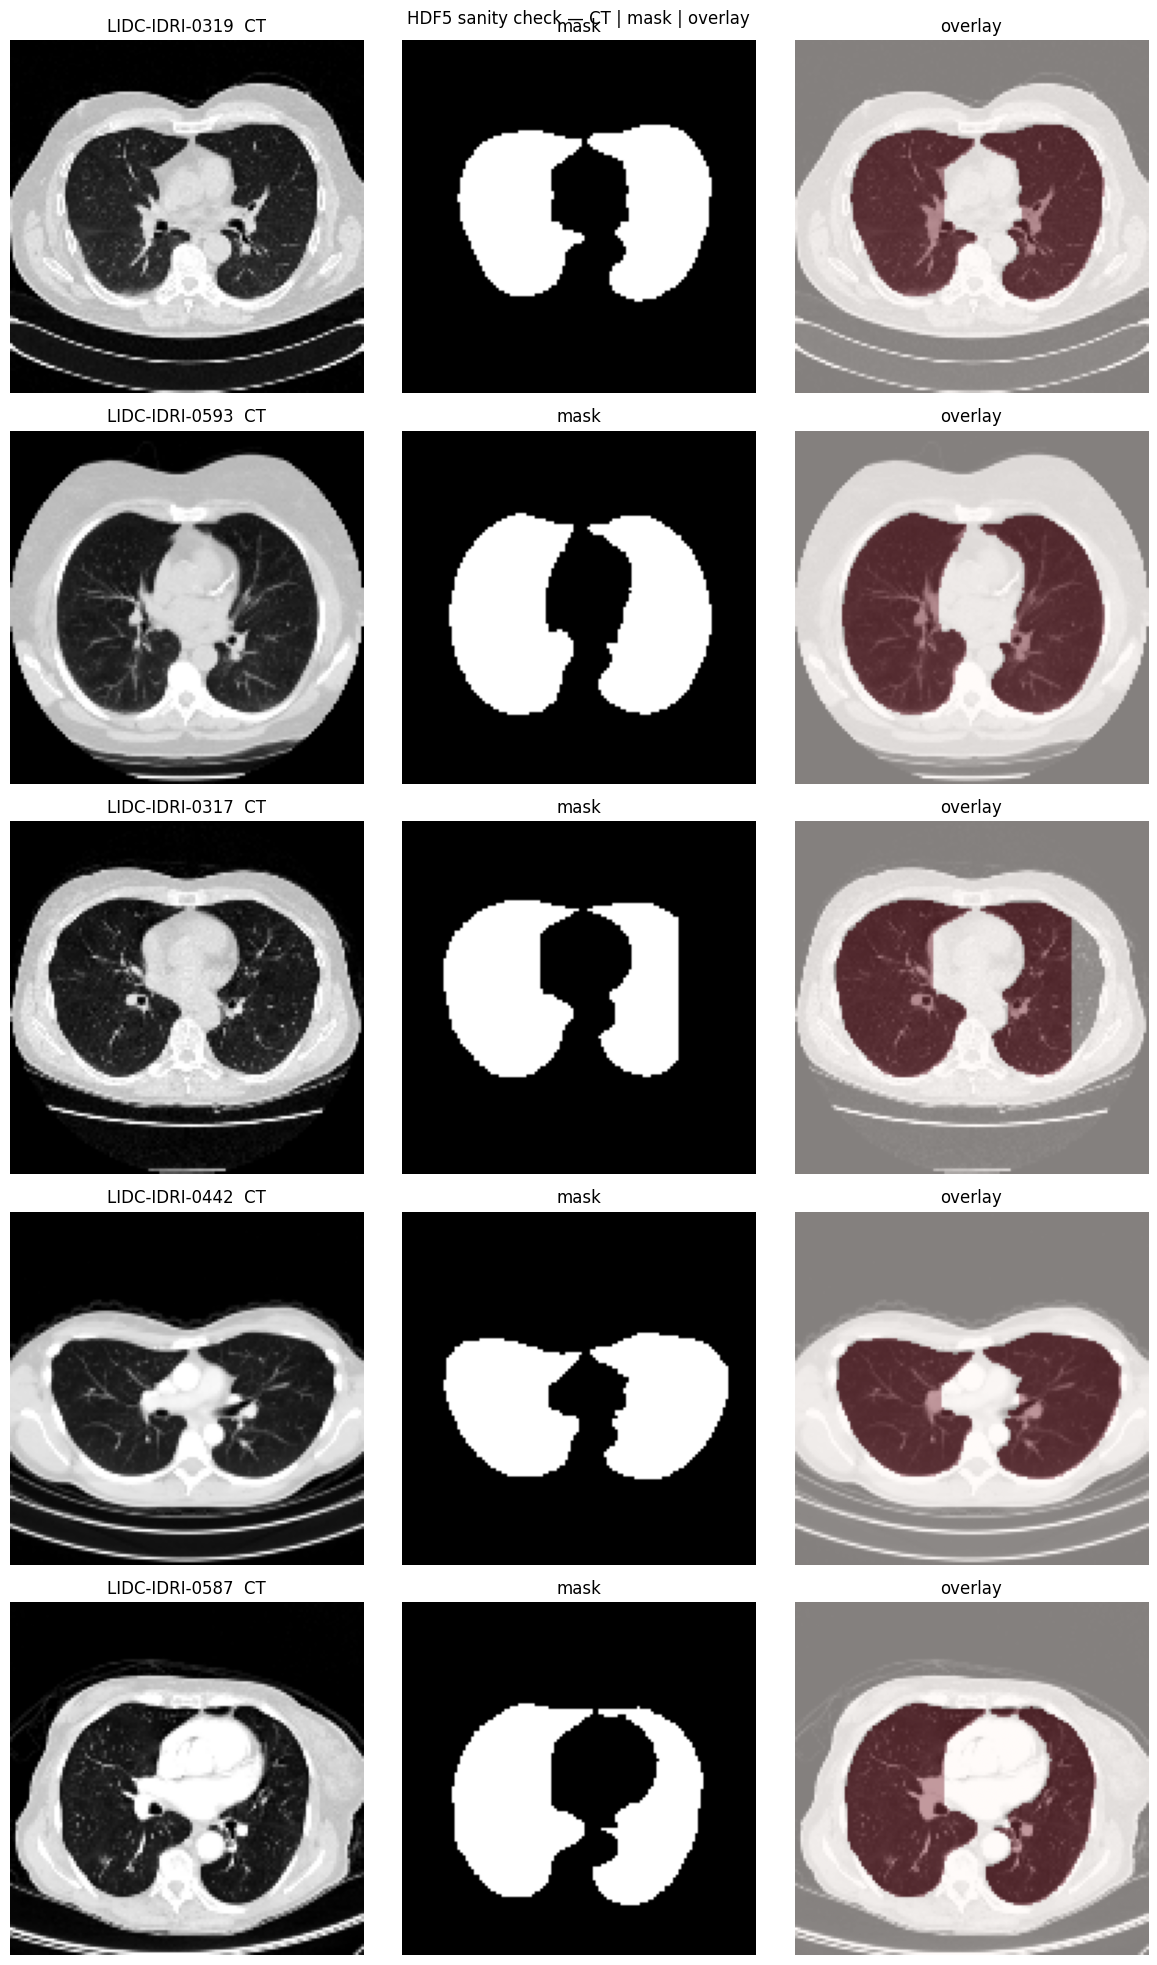


Visual check — each row should show:
  - CT  : two oval lung regions, spine dot at bottom center
  - mask: white ovals matching the lungs in the CT
  - overlay: red mask sitting precisely on the lung regions

If any row shows a side view (ribs as horizontal lines)
the axis fix did not take effect — do NOT proceed to Cell 7.


In [ ]:
# ── Cell 6b — Pre-upload sanity check ────────────────────────
# Run AFTER Cell 6 completes, BEFORE Cell 7 uploads to HF.
# Verifies axial orientation and correct resizing on 5 random
# patients directly from the freshly written HDF5.

import h5py, numpy as np, random
import matplotlib.pyplot as plt

N_CHECK = 5   # patients to spot-check

with h5py.File(H5_LOCAL, "r") as hf:
    all_patients = list(set(
        p.decode() if isinstance(p, bytes) else p
        for p in hf["patient"][:]
    ))
    sample_pids = random.sample(all_patients, min(N_CHECK, len(all_patients)))

    fig, axes = plt.subplots(N_CHECK, 3, figsize=(12, 4 * N_CHECK))
    fig.suptitle("HDF5 sanity check — CT | mask | overlay", fontsize=12)

    for row, pid in enumerate(sample_pids):
        # grab all indices for this patient, pick a lung slice
        indices = [
            i for i, p in enumerate(hf["patient"][:])
            if (p.decode() if isinstance(p, bytes) else p) == pid
            and (hf["kind"][i].decode() if isinstance(hf["kind"][i], bytes) else hf["kind"][i]) == "lung"
        ]
        if not indices:
            print(f"  [WARN] {pid}: no lung slices found in HDF5")
            continue

        idx     = indices[len(indices) // 2]   # mid lung slice for this patient
        img     = hf["img"][idx]               # (IMAGE_SIZE, IMAGE_SIZE)
        msk     = hf["msk"][idx]               # (IMAGE_SIZE, IMAGE_SIZE)

        # ── Checks ────────────────────────────────────────────
        assert img.shape == (IMAGE_SIZE, IMAGE_SIZE), \
            f"{pid}: wrong img shape {img.shape}"
        assert msk.shape == (IMAGE_SIZE, IMAGE_SIZE), \
            f"{pid}: wrong msk shape {msk.shape}"
        assert 0.0 <= img.mean() <= 1.0, \
            f"{pid}: img values out of [0,1] range: mean={img.mean():.3f}"
        assert msk.mean() > 0.001, \
            f"{pid}: lung slice has empty mask"
        assert np.all((msk == 0) | (msk == 1)), \
            f"{pid}: mask has non-binary values"

        axes[row, 0].imshow(img, cmap="gray")
        axes[row, 0].set_title(f"{pid}  CT")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(msk, cmap="gray")
        axes[row, 1].set_title("mask")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(img, cmap="gray", alpha=0.8)
        axes[row, 2].imshow(msk, cmap="Reds", alpha=0.4, vmin=0, vmax=1)
        axes[row, 2].set_title("overlay")
        axes[row, 2].axis("off")

        print(f"  [OK] {pid} | slice idx={idx} | "
              f"img mean={img.mean():.3f} | "
              f"mask coverage={msk.mean()*100:.1f}%")

plt.tight_layout()
plt.savefig("/content/hdf5_sanity_check.png", dpi=120, bbox_inches="tight")
plt.show()

print()
print("Visual check — each row should show:")
print("  - CT  : two oval lung regions, spine dot at bottom center")
print("  - mask: white ovals matching the lungs in the CT")
print("  - overlay: red mask sitting precisely on the lung regions")
print()
print("If any row shows a side view (ribs as horizontal lines)")
print("the axis fix did not take effect — do NOT proceed to Cell 7.")

In [ ]:
# ── Cell 7 — Final Upload to HuggingFace ─────────────────────────────────────
# Uploads the completed slices.h5 to HuggingFace.
# This cell is separate so you can re-run it alone if the upload was interrupted.

print("Final upload to HuggingFace...", flush=True)
_start   = time.time()
_up_done = threading.Event()
_up_err  = [None]

def _upload_worker():
    try:
        HfApi().upload_file(
            path_or_fileobj = H5_LOCAL,
            path_in_repo    = "slices.h5",
            repo_id         = HF_OUTPUT_REPO,
            repo_type       = "dataset",
            commit_message  = f"Final slices.h5 — {final_n} slices, "
                              f"{len(failed_pids)} failed patients",
        )
    except Exception as e:
        _up_err[0] = e
    finally:
        _up_done.set()

_up_thread = threading.Thread(target=_upload_worker, daemon=True)
_up_thread.start()

while not _up_done.wait(30):
    elapsed = int(time.time() - _start)
    print(f"  [{time.strftime('%H:%M:%S')}] Uploading... ({elapsed}s elapsed)", flush=True)

_up_thread.join()
if _up_err[0] is not None:
    raise RuntimeError(f"Final upload failed: {_up_err[0]}")

print(f"  Done in {round(time.time() - _start, 1)}s", flush=True)

if failed_pids:
    print(f"\n[WARN] {len(failed_pids)} patients failed and were skipped:")
    for pid in failed_pids[:20]:
        print(f"   {pid}")
    if len(failed_pids) > 20:
        print(f"   ... and {len(failed_pids) - 20} more.")
    print("Re-run Cell 6 to retry failed patients.")

print("\n[Cell 7 OK — Upload complete]")

Final upload to HuggingFace...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/slices.h5          :   0%|          | 15.9MB / 5.76GB            

  [18:10:34] Uploading... (30s elapsed)


No files have been modified since last commit. Skipping to prevent empty commit.


  Done in 49.7s

[Cell 7 OK — Upload complete]


In [ ]:
# ── Cell 8 — Verification ────────────────────────────────────────────────────
# Read-only. Verifies the HDF5 is complete and internally consistent.
# Run after Cell 7 completes.

import h5py, numpy as np, random, os

print("=" * 55)
print("VERIFICATION")
print("=" * 55)

with h5py.File(H5_LOCAL, "r") as hf:
    n_total  = hf["img"].shape[0]
    kinds    = np.array(hf["kind"])
    patients = list(hf["patient"])
    n_lung   = int(np.sum(kinds == b"lung"))
    n_empty  = int(np.sum(kinds == b"empty"))
    n_pats   = len(set(p.decode() for p in patients))

    print(f"\nHDF5 summary:")
    print(f"  Patients    : {n_pats} / {N_PATIENTS}")
    print(f"  Lung slices : {n_lung}")
    print(f"  Empty slices: {n_empty}")
    print(f"  Total slices: {n_total}")
    print(f"  Empty ratio : {n_empty/max(n_total,1)*100:.1f}% (expected ~{int(EMPTY_SLICE_RATIO*100)}%)")
    print(f"  File size   : {os.path.getsize(H5_LOCAL)/1e9:.2f} GB")

    # ── Check: no duplicate file names ───────────────────────────────────
    all_files = [f.decode() for f in hf["file"]]
    duplicates = len(all_files) - len(set(all_files))
    if duplicates == 0:
        print(f"\n[PASS] No duplicate filenames")
    else:
        print(f"\n[FAIL] {duplicates} duplicate filenames found")

    # ── Check: kind labels are valid ──────────────────────────────────────
    invalid_kind = int(np.sum((kinds != b"lung") & (kinds != b"empty")))
    if invalid_kind == 0:
        print(f"[PASS] All kind labels valid (lung or empty)")
    else:
        print(f"[FAIL] {invalid_kind} entries with invalid kind label")

    # ── Spot-check 200 random slices ──────────────────────────────────────
    print(f"\nSpot-checking 200 random slices...")
    indices = random.sample(range(n_total), min(200, n_total))
    failed_check = []

    for i, idx in enumerate(indices):
        try:
            img = hf["img"][idx]
            msk = hf["msk"][idx]
            assert img.shape == (IMAGE_SIZE, IMAGE_SIZE), f"img shape: {img.shape}"
            assert msk.shape == (IMAGE_SIZE, IMAGE_SIZE), f"msk shape: {msk.shape}"
            assert 0.0 <= float(img.mean()) <= 1.0,       f"img mean out of range: {img.mean()}"
            # Verify kind label matches actual mask content
            actual_kind = b"empty" if msk.mean() < MIN_MASK_RATIO else b"lung"
            assert actual_kind == kinds[idx], \
                f"kind mismatch: stored={kinds[idx]} actual={actual_kind}"
        except Exception as e:
            failed_check.append((idx, str(e)))
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/200 checked...")

    if not failed_check:
        print(f"[PASS] All 200 sampled slices readable, valid, kind labels correct")
    else:
        print(f"[FAIL] {len(failed_check)} slices failed:")
        for idx, err in failed_check:
            print(f"  slice {idx}: {err}")

print(f"\n{'=' * 55}")
all_passed = (n_pats == N_PATIENTS and duplicates == 0 and
              invalid_kind == 0 and not failed_check)
if all_passed:
    print("ALL CHECKS PASSED")
    print("Data preparation complete. Proceed to training.ipynb")
else:
    print("SOME CHECKS FAILED — see warnings above.")
print(f"{'=' * 55}")

print("\n[Cell 8 OK]")

VERIFICATION

HDF5 summary:
  Patients    : 996 / 996
  Lung slices : 97624
  Empty slices: 9614
  Total slices: 107238
  Empty ratio : 9.0% (expected ~10%)
  File size   : 5.76 GB

[FAIL] 418 duplicate filenames found
[PASS] All kind labels valid (lung or empty)

Spot-checking 200 random slices...
  50/200 checked...
  100/200 checked...
  150/200 checked...
  200/200 checked...
[PASS] All 200 sampled slices readable, valid, kind labels correct

SOME CHECKS FAILED — see warnings above.

[Cell 8 OK]


In [ ]:
# ── Cell 9 — Download HDF5 from HF, then export slice_index.json ─────────────

import h5py, json, os
from huggingface_hub import HfApi, hf_hub_download

HF_OUTPUT_REPO = "hourouu/data_unet128A"
H5_LOCAL       = "/content/slices.h5"
INDEX_LOCAL    = "/content/slice_index.json"
N_PATIENTS     = 100  # adjust if needed

# ── 1. Download slices.h5 from HuggingFace ───────────────────────────────────
if os.path.exists(H5_LOCAL):
    print(f"slices.h5 already exists locally ({os.path.getsize(H5_LOCAL)/1e9:.2f} GB), skipping download.")
else:
    print("Downloading slices.h5 from HuggingFace...", flush=True)
    hf_hub_download(
        repo_id   = HF_OUTPUT_REPO,
        repo_type = "dataset",
        filename  = "slices.h5",
        local_dir = "/content",
    )
    print(f"  Downloaded → {H5_LOCAL} ({os.path.getsize(H5_LOCAL)/1e9:.2f} GB)", flush=True)

# ── 2. Build slice_index.json from HDF5 ──────────────────────────────────────
print("Building slice_index.json from HDF5...", flush=True)

with h5py.File(H5_LOCAL, "r") as hf:
    files    = [f.decode() for f in hf["file"]]
    patients = [p.decode() for p in hf["patient"]]
    kinds    = [k.decode() for k in hf["kind"]]

slices = [
    {"file": f, "patient": p, "kind": k}
    for f, p, k in zip(files, patients, kinds)
]
processed_patients = sorted(set(patients))

idx = {
    "processed_patients": processed_patients,
    "slices":             slices,
}

# ── Write atomically ──────────────────────────────────────────────────────────
tmp_path = INDEX_LOCAL + ".tmp"
try:
    with open(tmp_path, "w") as f:
        json.dump(idx, f)
    with open(tmp_path) as f:
        verify = json.load(f)
    assert len(verify["slices"])             == len(slices),             "Slice count mismatch"
    assert len(verify["processed_patients"]) == len(processed_patients), "Patient count mismatch"
    os.replace(tmp_path, INDEX_LOCAL)
except Exception as e:
    if os.path.exists(tmp_path):
        os.remove(tmp_path)
    raise RuntimeError(f"Index export failed: {e}")

size_mb = os.path.getsize(INDEX_LOCAL) / 1e6
print(f"  slice_index.json written ({len(slices)} slices, "
      f"{len(processed_patients)} patients, {size_mb:.1f} MB)", flush=True)

# ── 3. Upload slice_index.json back to HuggingFace ───────────────────────────
print("Uploading slice_index.json to HuggingFace...", end="", flush=True)
try:
    HfApi().upload_file(
        path_or_fileobj = INDEX_LOCAL,
        path_in_repo    = "slice_index.json",
        repo_id         = HF_OUTPUT_REPO,
        repo_type       = "dataset",
        commit_message  = f"slice_index.json — {len(slices)} slices, "
                          f"{len(processed_patients)} patients",
    )
    print(" done.", flush=True)
except Exception as e:
    print(f" FAILED: {e}", flush=True)
    print("  Local file intact at /content/slice_index.json — retry upload manually.")

# ── Summary ───────────────────────────────────────────────────────────────────
n_lung  = sum(1 for k in kinds if k == "lung")
n_empty = sum(1 for k in kinds if k == "empty")

print(f"\n{'=' * 55}")
print("INDEX EXPORT COMPLETE")
print(f"  Patients : {len(processed_patients)} / {N_PATIENTS}")
print(f"  Lung     : {n_lung}")
print(f"  Empty    : {n_empty}")
print(f"  Total    : {len(slices)}")
if len(processed_patients) == N_PATIENTS:
    print("ALL PATIENTS PRESENT — proceed to training.ipynb")
else:
    print(f"WARNING: only {len(processed_patients)}/{N_PATIENTS} patients present.")
print(f"{'=' * 55}")

print("\n[Cell 9 OK]")

slices.h5 already exists locally (5.76 GB), skipping download.
Building slice_index.json from HDF5...
  slice_index.json written (107238 slices, 996 patients, 8.9 MB)
Uploading slice_index.json to HuggingFace... done.

INDEX EXPORT COMPLETE
  Patients : 996 / 100
  Lung     : 97624
  Empty    : 9614
  Total    : 107238

[Cell 9 OK]


In [ ]:
# ── Checkpoint Recovery — Rebuild slices_progress.json from slices.h5 ────────
# Run this if you lost slices_progress.json but still have slices.h5 on HF.
# It reads every patient ID recorded inside slices.h5 and reconstructs the
# progress file, then uploads it so Cell 6 can resume correctly.

import h5py, json, os
from huggingface_hub import HfApi, hf_hub_download

H5_LOCAL    = "/content/slices.h5"
H5_PROGRESS = "/content/slices_progress.json"
HF_OUTPUT_REPO = "hourouu/data_unet128A"

# ── Step 1: download slices.h5 from HF if not already local ──────────────────
if not os.path.exists(H5_LOCAL):
    print("Downloading slices.h5 from HF...", flush=True)
    hf_hub_download(
        repo_id=HF_OUTPUT_REPO, filename="slices.h5",
        repo_type="dataset", local_dir="/content", force_download=True)
    print(f"  Downloaded → {H5_LOCAL}", flush=True)
else:
    print(f"slices.h5 already local ({os.path.getsize(H5_LOCAL)/1e9:.2f} GB)")

# ── Step 2: read patient list and slice count directly from the HDF5 ─────────
print("Reading slices.h5...", flush=True)
with h5py.File(H5_LOCAL, "r") as hf:
    total_slices       = hf["img"].shape[0]
    raw_patients       = hf["patient"][:]
    processed_patients = sorted(set(
        p.decode() if isinstance(p, bytes) else p
        for p in raw_patients
    ))

print(f"  Total slices       : {total_slices}")
print(f"  Unique patients    : {len(processed_patients)}")
print(f"  First 5 patients   : {processed_patients[:5]}")

# ── Step 3: write the recovered progress JSON ─────────────────────────────────
recovered = {
    "written":            total_slices,
    "processed_patients": processed_patients,
    "failed_patients":    [],        # unknown — conservatively left empty
    "session_slices":     0,
    "session_errors":     0,
}

with open(H5_PROGRESS, "w") as f:
    json.dump(recovered, f)

print(f"\nWrote {H5_PROGRESS}")

# ── Step 4: upload recovered progress JSON to HF ─────────────────────────────
print("Uploading slices_progress.json to HF...", end="", flush=True)
HfApi().upload_file(
    path_or_fileobj = H5_PROGRESS,
    path_in_repo    = "slices_progress.json",
    repo_id         = HF_OUTPUT_REPO,
    repo_type       = "dataset",
    commit_message  = f"Recovered progress — {len(processed_patients)} patients, {total_slices} slices",
)
print(" done.", flush=True)

print("\nRecovery complete. You can now re-run Cell 6 safely.")

slices.h5 already local (5.76 GB)
Reading slices.h5...
  Total slices       : 107238
  Unique patients    : 996
  First 5 patients   : ['LIDC-IDRI-0001', 'LIDC-IDRI-0002', 'LIDC-IDRI-0003', 'LIDC-IDRI-0004', 'LIDC-IDRI-0005']

Wrote /content/slices_progress.json
Uploading slices_progress.json to HF...

No files have been modified since last commit. Skipping to prevent empty commit.


 done.

Recovery complete. You can now re-run Cell 6 safely.
